<a href="https://colab.research.google.com/github/christophertritt/geospatial/blob/main/CVLZ_SLU_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install osmnx geopandas shapely


In [ ]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import zipfile
import os

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving slu_boundary.zip to slu_boundary (4).zip


In [ ]:
with zipfile.ZipFile('slu_boundary (4).zip', 'r') as z:
    z.extractall('slu_folder')

print(os.listdir('slu_folder'))


['boundary.sbx', 'boundary.shp.xml', 'boundary.shx', 'boundary.dbf', 'boundary.cpg', 'boundary.sbn', 'boundary.prj', 'boundary.shp']


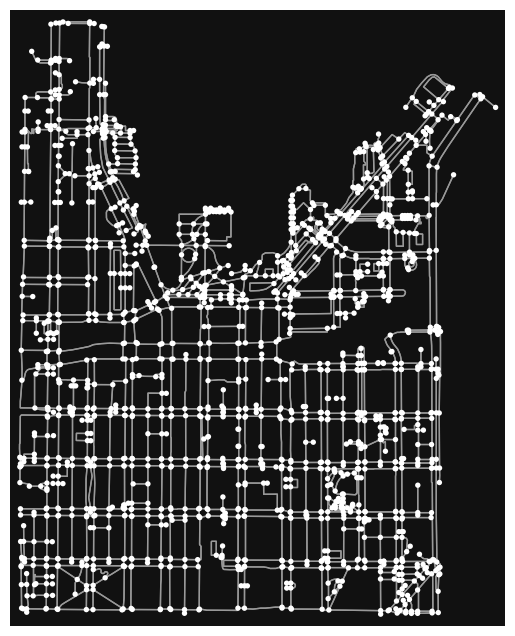

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
slu_boundary = gpd.read_file('slu_folder/boundary.shp')
slu_boundary = slu_boundary.to_crs(epsg=4326)

# Use the polygon directly instead of bbox
polygon = slu_boundary.geometry.union_all()

G = ox.graph_from_polygon(polygon, network_type="walk")
ox.plot_graph(G)


In [ ]:
uploaded = files.upload()  # upload CVLZ_Centroids.csv

loading_zones = pd.read_csv('CVLZ_Centroids.csv')
print(loading_zones.head())
print(loading_zones.columns)


Saving CVLZ_Centroids.csv to CVLZ_Centroids.csv
   OBJECTID BLOCKID  BLOCK_ST  BLOCK_END  WIDTH_OFFS  GEOBASYS  SPACELENGT  \
0         1  NTY-01      75.0      113.0          28         0          38   
1         2  NFV-02      57.5       93.5         -16         0          36   
2         3   N4-12     113.0      130.0          23         0          17   
3         4   N4-08     179.5      222.5          28         0          43   
4         5   N6-10      71.0      114.0         -27         0          43   

  SPACETYPE                    SPACETYPED  TIME_LIMIT  ... PRIMARYDIS  \
0      CVLZ  COMMERCIAL VEHICLE LOAD ZONE          30  ...  DISTRICT7   
1      CVLZ  COMMERCIAL VEHICLE LOAD ZONE          30  ...  DISTRICT7   
2      CVLZ  COMMERCIAL VEHICLE LOAD ZONE          30  ...  DISTRICT7   
3      CVLZ  COMMERCIAL VEHICLE LOAD ZONE          30  ...  DISTRICT7   
4      CVLZ  COMMERCIAL VEHICLE LOAD ZONE          30  ...  DISTRICT7   

  SECONDARYD OVERRIDEYN OVERRIDECO          

In [ ]:
# Convert loading zone coordinates to WGS84
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:2926", "EPSG:4326", always_xy=True)

loading_zones['lon'], loading_zones['lat'] = transformer.transform(
    loading_zones['POINT_X'].values,
    loading_zones['POINT_Y'].values
)

print(loading_zones[['OBJECTID', 'BLOCKID', 'lat', 'lon']].head())


   OBJECTID BLOCKID        lat         lon
0         1  NTY-01  47.618789 -122.337283
1         2  NFV-02  47.619878 -122.334212
2         3   N4-12  47.622040 -122.332516
3         4   N4-08  47.622131 -122.340267
4         5   N6-10  47.624478 -122.336772


In [ ]:
# Snap each loading zone to nearest node on the network
loading_zones['nearest_node'] = loading_zones.apply(
    lambda row: ox.nearest_nodes(G, row['lon'], row['lat']), axis=1
)

print(loading_zones[['OBJECTID', 'BLOCKID', 'lat', 'lon', 'nearest_node']].head())


   OBJECTID BLOCKID        lat         lon  nearest_node
0         1  NTY-01  47.618789 -122.337283    7811511699
1         2  NFV-02  47.619878 -122.334212    5771940606
2         3   N4-12  47.622040 -122.332516   10650694464
3         4   N4-08  47.622131 -122.340267   10607422007
4         5   N6-10  47.624478 -122.336772    5772364363


In [ ]:
import networkx as nx

nodes = loading_zones['nearest_node'].tolist()
ids = loading_zones['BLOCKID'].tolist()

# Calculate shortest path lengths between all pairs
results = []

for i, (node_a, id_a) in enumerate(zip(nodes, ids)):
    for j, (node_b, id_b) in enumerate(zip(nodes, ids)):
        if i >= j:
            continue
        try:
            length = nx.shortest_path_length(G, node_a, node_b, weight='length')
            results.append({'from': id_a, 'to': id_b, 'distance_m': length})
        except nx.NetworkXNoPath:
            results.append({'from': id_a, 'to': id_b, 'distance_m': None})

distance_df = pd.DataFrame(results)
print(distance_df.head(10))
print(f"\nTotal pairs calculated: {len(distance_df)}")


     from      to   distance_m
0  NTY-01  NFV-02   362.727787
1  NTY-01   N4-12   752.618912
2  NTY-01   N4-08   613.780705
3  NTY-01   N6-10   681.526627
4  NTY-01   N6-12  1086.142216
5  NTY-01   EE-11  1708.365528
6  NTY-01   N2-09   147.109579
7  NTY-01  NBN-01   121.895884
8  NTY-01  NTY-01     0.000000
9  NTY-01  NDR-10  1431.203066

Total pairs calculated: 136


In [ ]:
# Save full distance matrix
distance_df.to_csv('loading_zone_distances.csv', index=False)

# Find the nearest loading zone for each zone
nearest = distance_df[distance_df['distance_m'] > 0].groupby('from').apply(
    lambda x: x.loc[x['distance_m'].idxmin()]
).reset_index(drop=True)

nearest = nearest.rename(columns={'to': 'nearest_zone', 'distance_m': 'nearest_distance_m'})
print(nearest[['from', 'nearest_zone', 'nearest_distance_m']])

nearest.to_csv('nearest_loading_zones.csv', index=False)


      from nearest_zone  nearest_distance_m
0    EE-11        N8-13          559.990246
1   N09-07       NDR-11          498.360952
2    N2-09       NTY-01          147.109579
3    N4-08        N2-09          466.729637
4    N4-12        N4-12           72.959357
5    N5-12        N4-12          145.880067
6    N6-10       N09-07          418.752101
7    N6-12        N5-12          209.971313
8    N8-13       NDR-11         1205.233627
9   NBN-01       NTY-01          121.895884
10  NDR-10       NDR-11           41.109915
11  NDR-11       NDR-13          246.326130
12  NFV-02       NBN-01          240.831903
13  NTY-01       NBN-01          121.895884


/tmp/ipykernel_987/27116770.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nearest = distance_df[distance_df['distance_m'] > 0].groupby('from').apply(


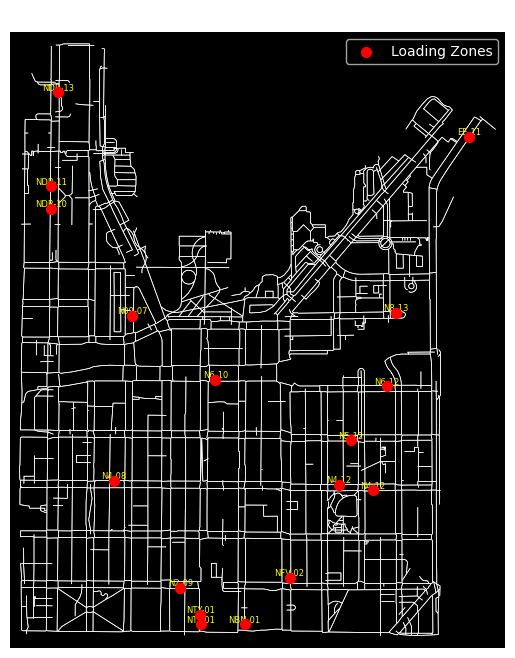

In [ ]:
import matplotlib.pyplot as plt

fig, ax = ox.plot_graph(G, show=False, close=False, bgcolor='black',
                         node_size=0, edge_color='white', edge_linewidth=0.5)

# Plot loading zones on top
ax.scatter(loading_zones['lon'], loading_zones['lat'],
           c='red', s=50, zorder=5, label='Loading Zones')

# Label each zone
for _, row in loading_zones.iterrows():
    ax.annotate(row['BLOCKID'], (row['lon'], row['lat']),
                color='yellow', fontsize=6, ha='center', va='bottom')

ax.legend(loc='upper right', facecolor='black', labelcolor='white')
plt.title('SLU Loading Zones on Walking Network', color='white')
plt.savefig('slu_loading_zones_network.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Find all parcels (nodes) within 75m walking distance of each loading zone
service_coverage = []

for _, lz in loading_zones.iterrows():
    # Get all nodes within 75m network distance
    subgraph = nx.ego_graph(G, lz['nearest_node'], radius=75, distance='length')
    covered_nodes = list(subgraph.nodes)

    service_coverage.append({
        'BLOCKID': lz['BLOCKID'],
        'covered_nodes': covered_nodes,
        'node_count': len(covered_nodes)
    })

coverage_df = pd.DataFrame(service_coverage)
print(coverage_df[['BLOCKID', 'node_count']])


   BLOCKID  node_count
0   NTY-01           4
1   NFV-02          12
2    N4-12          19
3    N4-08          15
4    N6-10          11
5    N6-12          20
6    EE-11           5
7    N2-09          10
8   NBN-01           5
9   NTY-01           4
10  NDR-10          11
11   N5-12          19
12  N09-07           8
13   N4-12          20
14   N8-13          11
15  NDR-11          11
16  NDR-13          13


In [ ]:
thresholds = [75, 150, 225]
sensitivity_results = []

for radius in thresholds:
    for _, lz in loading_zones.iterrows():
        subgraph = nx.ego_graph(G, lz['nearest_node'], radius=radius, distance='length')
        sensitivity_results.append({
            'BLOCKID': lz['BLOCKID'],
            'threshold_m': radius,
            'node_count': len(subgraph.nodes)
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

pivot = sensitivity_df.pivot_table(index='BLOCKID', columns='threshold_m', values='node_count')
print(pivot)
pivot.to_csv('sensitivity_analysis.csv')


threshold_m   75    150    225
BLOCKID                       
EE-11         5.0  29.0   45.0
N09-07        8.0  28.0   64.0
N2-09        10.0  25.0   57.0
N4-08        15.0  41.0  117.0
N4-12        19.5  71.5  160.5
N5-12        19.0  71.0  143.0
N6-10        11.0  36.0  100.0
N6-12        20.0  42.0   84.0
N8-13        11.0  52.0  100.0
NBN-01        5.0  21.0   40.0
NDR-10       11.0  18.0   45.0
NDR-11       11.0  25.0   56.0
NDR-13       13.0  26.0   52.0
NFV-02       12.0  43.0   82.0
NTY-01        4.0  13.0   34.0


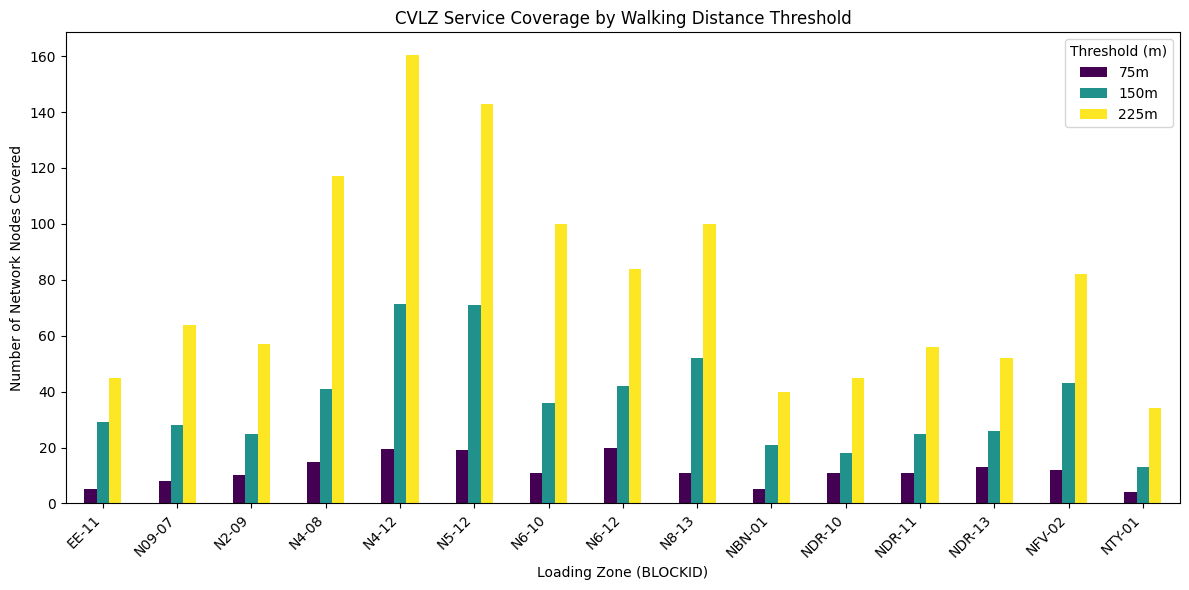

In [ ]:
import matplotlib.pyplot as plt

pivot.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('CVLZ Service Coverage by Walking Distance Threshold')
plt.xlabel('Loading Zone (BLOCKID)')
plt.ylabel('Number of Network Nodes Covered')
plt.legend(title='Threshold (m)', labels=['75m', '150m', '225m'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sensitivity_analysis_chart.png', dpi=150)
plt.show()


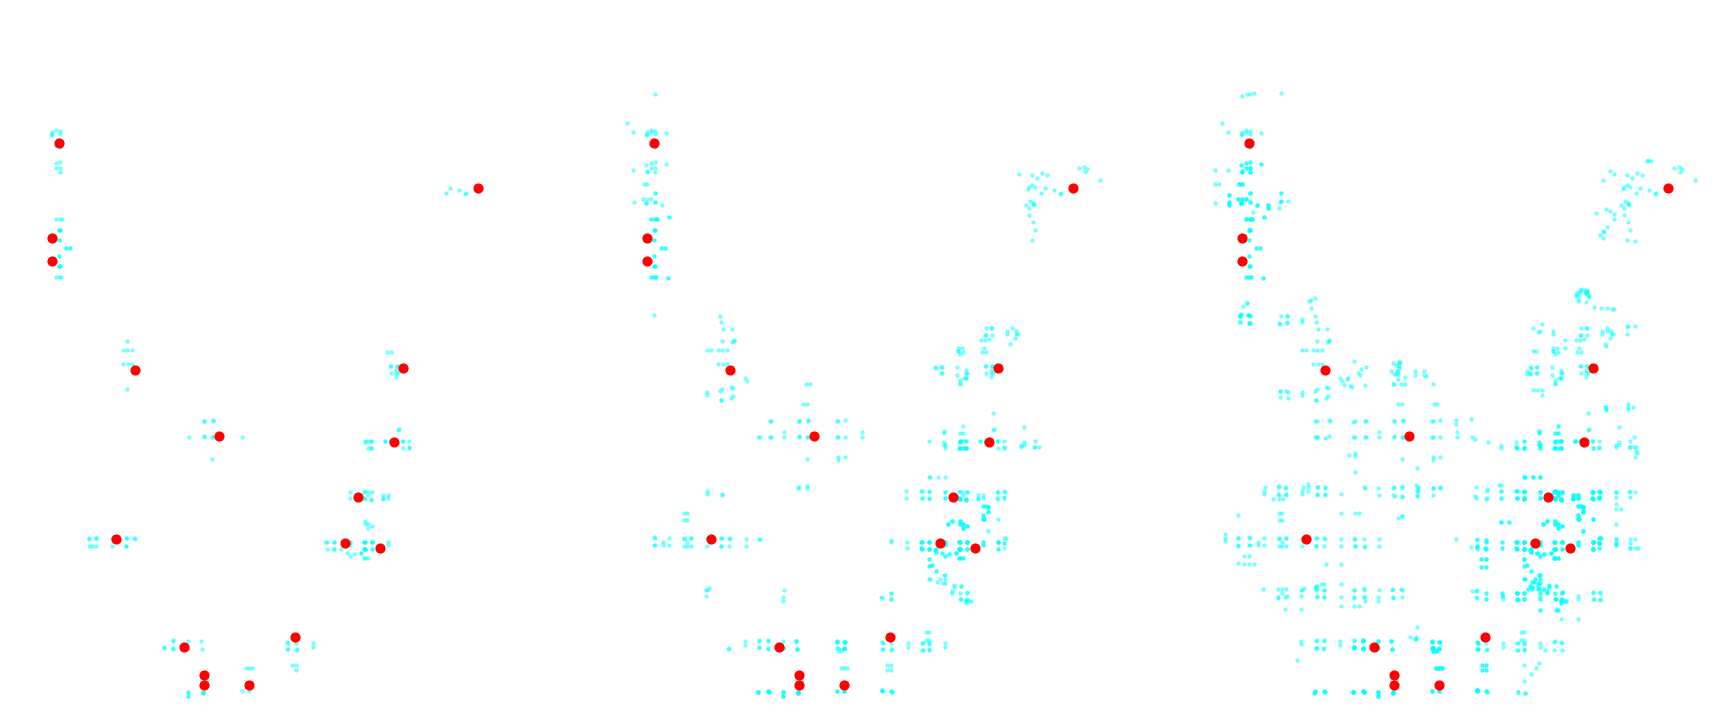

In [ ]:
from shapely.geometry import Point
import geopandas as gpd

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
thresholds = [75, 150, 225]

for ax, radius in zip(axes, thresholds):
    # Plot base network
    ox.plot_graph(G, ax=ax, show=False, close=False,
                  bgcolor='black', node_size=0,
                  edge_color='white', edge_linewidth=0.5)

    # Plot service area for each loading zone
    for _, lz in loading_zones.iterrows():
        subgraph = nx.ego_graph(G, lz['nearest_node'], radius=radius, distance='length')
        node_coords = [(G.nodes[n]['x'], G.nodes[n]['y']) for n in subgraph.nodes]
        xs, ys = zip(*node_coords)
        ax.scatter(xs, ys, c='cyan', s=5, alpha=0.4, zorder=3)

    # Plot loading zones on top
    ax.scatter(loading_zones['lon'], loading_zones['lat'],
               c='red', s=40, zorder=5)

    ax.set_title(f'{radius}m Threshold', color='white', fontsize=12)

plt.suptitle('CVLZ Service Coverage — Sensitivity Analysis',
             color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('service_area_map.png', dpi=150, bbox_inches='tight',
            facecolor='black')
plt.show()


In [ ]:
export_rows = []

for radius in [75, 150, 225]:
    for _, lz in loading_zones.iterrows():
        subgraph = nx.ego_graph(G, lz['nearest_node'], radius=radius, distance='length')
        for node in subgraph.nodes:
            export_rows.append({
                'BLOCKID': lz['BLOCKID'],
                'threshold_m': radius,
                'x': G.nodes[node]['x'],
                'y': G.nodes[node]['y']
            })

export_df = pd.DataFrame(export_rows)
export_df.to_csv('cvlz_coverage_nodes.csv', index=False)
print(f"Total rows exported: {len(export_df)}")


Total rows exported: 2198


In [ ]:
uploaded = files.upload()  # upload SLU_hotspots.csv

hotspots = pd.read_csv('SLU_hotspots.csv')
print(hotspots.head())
print(hotspots.columns.tolist())
print(f"Total parcels: {len(hotspots)}")


Saving SLU_hotspots.csv to SLU_hotspots.csv
   SOURCE_ID  Weights  GiZScore  GiPValue  NNeighbors  Gi_Bin       POINT_X  \
0          1        1 -0.494077  0.621252           6       0  1.268850e+06   
1          2        6 -1.403906  0.160347           7       0  1.268559e+06   
2          3        1 -1.750647  0.080007          11      -1  1.268691e+06   
3          4        6  1.252750  0.210297           1       0  1.270083e+06   
4          5        3 -1.176315  0.239469           6       0  1.270529e+06   

         POINT_Y  
0  230664.752050  
1  234289.549263  
2  229846.445288  
3  230297.366630  
4  231239.375901  
['SOURCE_ID', 'Weights', 'GiZScore', 'GiPValue', 'NNeighbors', 'Gi_Bin', 'POINT_X', 'POINT_Y']
Total parcels: 407


In [ ]:
# Convert hotspot coordinates to WGS84
hotspots['lon'], hotspots['lat'] = transformer.transform(
    hotspots['POINT_X'].values,
    hotspots['POINT_Y'].values
)

# For each loading zone and threshold, find hotspot parcels within service area
results = []

for radius in [75, 150, 225]:
    for _, lz in loading_zones.iterrows():
        # Get all nodes within radius
        subgraph = nx.ego_graph(G, lz['nearest_node'], radius=radius, distance='length')

        # Get covered node coordinates
        covered_nodes = [(G.nodes[n]['x'], G.nodes[n]['y']) for n in subgraph.nodes]

        # Find hotspot parcels within radius of any covered node
        count_total = 0
        count_hotspot = 0  # Gi_Bin > 0

        for _, parcel in hotspots.iterrows():
            for nx_lon, nx_lat in covered_nodes:
                dist = ((parcel['lon'] - nx_lon)**2 + (parcel['lat'] - nx_lat)**2)**0.5 * 111000
                if dist <= radius:
                    count_total += 1
                    if parcel['Gi_Bin'] > 0:
                        count_hotspot += 1
                    break

        results.append({
            'BLOCKID': lz['BLOCKID'],
            'threshold_m': radius,
            'parcels_covered': count_total,
            'hotspot_parcels_covered': count_hotspot
        })

results_df = pd.DataFrame(results)
pivot_total = results_df.pivot_table(index='BLOCKID', columns='threshold_m', values='parcels_covered')
pivot_hotspot = results_df.pivot_table(index='BLOCKID', columns='threshold_m', values='hotspot_parcels_covered')

print("Total parcels covered:")
print(pivot_total)
print("\nHot spot parcels covered (Gi_Bin > 0):")
print(pivot_hotspot)

results_df.to_csv('cvlz_parcel_coverage.csv', index=False)


Total parcels covered:
threshold_m   75    150    225
BLOCKID                       
EE-11         7.0  20.0   26.0
N09-07        8.0  23.0   59.0
N2-09        10.0  43.0   85.0
N4-08        11.0  73.0  122.0
N4-12        10.5  74.5  125.0
N5-12        14.0  65.0  121.0
N6-10        11.0  40.0  103.0
N6-12        10.0  36.0   83.0
N8-13         6.0  27.0   49.0
NBN-01        5.0  19.0   65.0
NDR-10       11.0  36.0   68.0
NDR-11       11.0  36.0   68.0
NDR-13       10.0  39.0   57.0
NFV-02        7.0  47.0   95.0
NTY-01        3.0  25.0   64.0

Hot spot parcels covered (Gi_Bin > 0):
threshold_m  75    150   225
BLOCKID                     
EE-11        6.0  13.0  13.0
N09-07       5.0   7.0  17.0
N2-09        0.0   8.0  27.0
N4-08        5.0  27.0  41.0
N4-12        0.0   2.0   9.0
N5-12        0.0   0.0   6.0
N6-10        5.0  17.0  38.0
N6-12        0.0   0.0   3.0
N8-13        1.0   2.0   3.0
NBN-01       0.0   0.0   7.0
NDR-10       0.0   0.0   0.0
NDR-11       0.0   0.0   0.0
NDR-

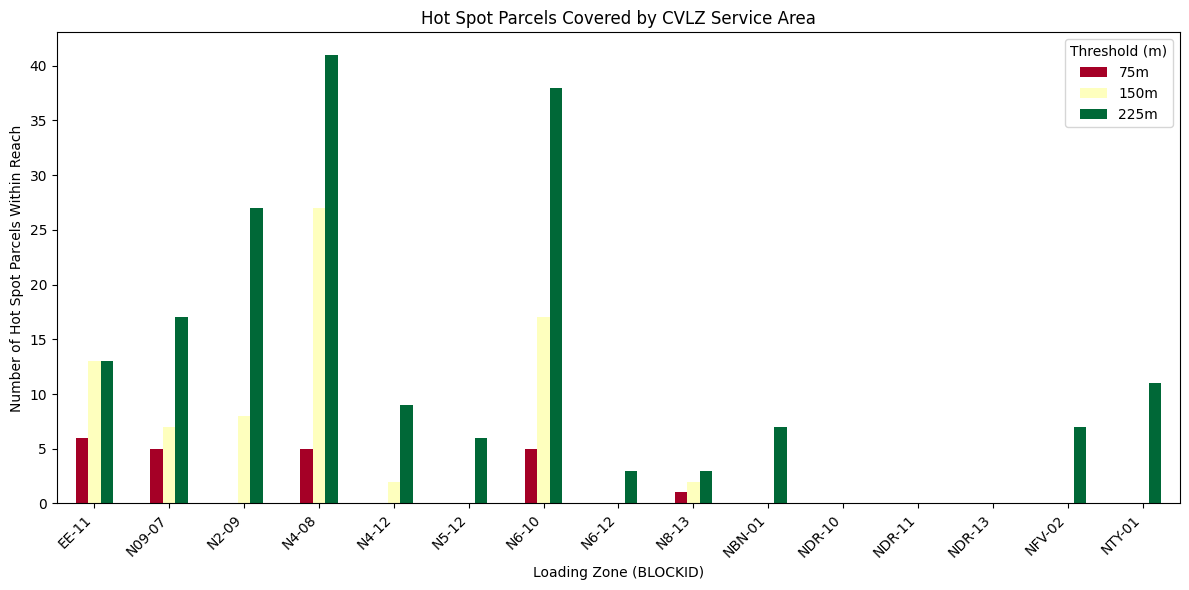

In [ ]:
pivot_hotspot.plot(kind='bar', figsize=(12, 6), colormap='RdYlGn')
plt.title('Hot Spot Parcels Covered by CVLZ Service Area')
plt.xlabel('Loading Zone (BLOCKID)')
plt.ylabel('Number of Hot Spot Parcels Within Reach')
plt.legend(title='Threshold (m)', labels=['75m', '150m', '225m'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hotspot_coverage_chart.png', dpi=150)
plt.show()


In [ ]:
loading_zones['BLOCKID'].nunique()
loading_zones[['BLOCKID']].drop_duplicates().sort_values('BLOCKID')


,BLOCKID
6,EE-11
12,N09-07
7,N2-09
3,N4-08
2,N4-12
11,N5-12
4,N6-10
5,N6-12
14,N8-13
8,NBN-01


In [ ]:
import os
print(os.getcwd())
print(os.listdir())


/content
['.config', 'slu_boundary (4).zip', 'boundary.sbx', 'boundary.shp.xml', 'nearest_loading_zones.csv', 'cache', 'slu_folder', 'boundary.shx', 'sensitivity_analysis_chart.png', 'SLU_boundary.shp', 'SLU_hotspots.csv', 'slu_boundary (3).zip', 'CVLZ_Centroids.csv', 'slu_boundary (2).zip', 'boundary.dbf', 'service_area_map.png', 'boundary.shp.DORY.32928.19552.sr.lock', 'boundary.shp.DORY.29224.19552.sr.lock', 'boundary.cpg', 'sensitivity_analysis.csv', 'boundary.sbn', 'boundary.shp.DORY.26076.19552.sr.lock', 'cvlz_parcel_coverage.csv', 'slu_boundary.zip', 'cvlz_coverage_nodes.csv', 'hotspot_coverage_chart.png', 'loading_zone_distances.csv', 'boundary.prj', 'slu_boundary (1).zip', 'boundary.shp', 'slu_loading_zones_network.png', 'boundary.shp.DORY.32564.19552.sr.lock', 'sample_data']


In [ ]:
import os
print(os.listdir())


['.config', 'slu_boundary (4).zip', 'boundary.sbx', 'boundary.shp.xml', 'nearest_loading_zones.csv', 'cvlz_hotspot_join.csv', 'cache', 'slu_folder', 'boundary.shx', 'sensitivity_analysis_chart.png', 'SLU_boundary.shp', 'SLU_hotspots.csv', 'slu_boundary (3).zip', 'CVLZ_Centroids.csv', 'slu_boundary (2).zip', 'boundary.dbf', 'service_area_map.png', 'boundary.shp.DORY.32928.19552.sr.lock', 'cvlz.csv', 'boundary.shp.DORY.29224.19552.sr.lock', 'boundary.cpg', 'sensitivity_analysis.csv', 'boundary.sbn', 'boundary.shp.DORY.26076.19552.sr.lock', 'cvlz_parcel_coverage.csv', 'slu_boundary.zip', 'cvlz_coverage_nodes.csv', 'hotspot_coverage_chart.png', 'loading_zone_distances.csv', 'boundary.prj', 'slu_boundary (1).zip', 'boundary.shp', 'slu_loading_zones_network.png', 'boundary.shp.DORY.32564.19552.sr.lock', 'sample_data']


In [ ]:
import pandas as pd

cvlz = pd.read_csv("cvlz.csv")
hot = pd.read_csv("cvlz_hotspot_join.csv")


In [ ]:
cvlz_keep = cvlz[['BLOCKID','SPACELENGT','TIME_LIMIT',
                  'SIDE','CURRENT_ST','PRIMARYDIS',
                  'SUBAREA','Shape_Length']].copy()

print(len(cvlz_keep))     # should be 17
cvlz_keep.head()


17


,BLOCKID,SPACELENGT,TIME_LIMIT,SIDE,CURRENT_ST,PRIMARYDIS,SUBAREA,Shape_Length
0,NTY-01,38,30,W,INSVC,DISTRICT7,South,37.916218
1,NFV-02,36,30,E,INSVC,DISTRICT7,South,35.949808
2,N4-12,17,30,N,INSVC,DISTRICT7,South,16.953072
3,N4-08,43,30,N,INSVC,DISTRICT7,South,42.878311
4,N6-10,43,30,S,INSVC,DISTRICT7,South,42.956129


In [ ]:
df = hot.merge(cvlz_keep, on='BLOCKID', how='inner')

print(df['BLOCKID'].nunique())   # should be 17
df.head()


15


,Join_Count,TARGET_FID,BLOCKID,threshold_m,x,y,SOURCE_ID,Weights,GiZScore,GiPValue,NNeighbors,Gi_Bin,SPACELENGT,TIME_LIMIT,SIDE,CURRENT_ST,PRIMARYDIS,SUBAREA,Shape_Length
0,0,1,NTY-01,75,-122.337838,47.618538,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
1,0,1,NTY-01,75,-122.337838,47.618538,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
2,0,2,NTY-01,75,-122.337323,47.618634,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
3,0,2,NTY-01,75,-122.337323,47.618634,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
4,0,3,NTY-01,75,-122.337339,47.618618,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218


In [ ]:
df.to_csv("cvlz_hotspot_17zones.csv", index=False)


In [ ]:
df.shape
df['BLOCKID'].unique()
df.head()


,Join_Count,TARGET_FID,BLOCKID,threshold_m,x,y,SOURCE_ID,Weights,GiZScore,GiPValue,NNeighbors,Gi_Bin,SPACELENGT,TIME_LIMIT,SIDE,CURRENT_ST,PRIMARYDIS,SUBAREA,Shape_Length
0,0,1,NTY-01,75,-122.337838,47.618538,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
1,0,1,NTY-01,75,-122.337838,47.618538,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
2,0,2,NTY-01,75,-122.337323,47.618634,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
3,0,2,NTY-01,75,-122.337323,47.618634,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218
4,0,3,NTY-01,75,-122.337339,47.618618,NaN,NaN,NaN,NaN,NaN,NaN,38,30,W,INSVC,DISTRICT7,South,37.916218


In [ ]:
print(df.columns.tolist())


['Join_Count', 'TARGET_FID', 'BLOCKID', 'threshold_m', 'x', 'y', 'SOURCE_ID', 'Weights', 'GiZScore', 'GiPValue', 'NNeighbors', 'Gi_Bin', 'SPACELENGT', 'TIME_LIMIT', 'SIDE', 'CURRENT_ST', 'PRIMARYDIS', 'SUBAREA', 'Shape_Length']


In [ ]:
# 1) Build one-row-per-CVLZ view with the correct column names
cols = ['BLOCKID', 'SPACELENGT', 'TIME_LIMIT', 'SIDE',
        'Join_Count', 'GiZScore', 'GiPValue']

df_view = df[cols].drop_duplicates(subset='BLOCKID')
df_view


,BLOCKID,SPACELENGT,TIME_LIMIT,SIDE,Join_Count,GiZScore,GiPValue
0,NTY-01,38,30,W,0,NaN,NaN
8,NFV-02,36,30,E,0,NaN,NaN
20,N4-12,17,30,N,0,NaN,NaN
58,N4-08,43,30,N,0,NaN,NaN
73,N6-10,43,30,S,0,NaN,NaN
84,N6-12,34,30,N,0,NaN,NaN
104,EE-11,34,30,SE,0,NaN,NaN
109,N2-09,41,30,S,0,NaN,NaN
119,NBN-01,42,30,E,0,NaN,NaN
132,NDR-10,29,30,W,0,NaN,NaN


In [ ]:
df_sorted = df_view.sort_values('GiZScore', ascending=False)
df_sorted


,BLOCKID,SPACELENGT,TIME_LIMIT,SIDE,Join_Count,GiZScore,GiPValue
0,NTY-01,38,30,W,0,NaN,NaN
8,NFV-02,36,30,E,0,NaN,NaN
20,N4-12,17,30,N,0,NaN,NaN
58,N4-08,43,30,N,0,NaN,NaN
73,N6-10,43,30,S,0,NaN,NaN
84,N6-12,34,30,N,0,NaN,NaN
104,EE-11,34,30,SE,0,NaN,NaN
109,N2-09,41,30,S,0,NaN,NaN
119,NBN-01,42,30,E,0,NaN,NaN
132,NDR-10,29,30,W,0,NaN,NaN


In [ ]:
df_sorted.to_csv("cvlz_hotspot_summary_17zones.csv", index=False)


In [ ]:
import pandas as pd

cvlz = pd.read_csv("cvlz.csv")
hot = pd.read_csv("cvlz_hotspot_join.csv")

cvlz_keep = cvlz[['BLOCKID','SPACELENGT','TIME_LIMIT','SIDE',
                  'CURRENT_ST','PRIMARYDIS','SUBAREA','Shape_Length']].copy()

hot.columns = hot.columns.str.strip()

df = hot.merge(cvlz_keep, on='BLOCKID', how='inner')

cols = ['BLOCKID', 'SPACELENGT', 'TIME_LIMIT', 'SIDE',
        'Join_Count', 'GiZScore', 'GiPValue']

plot_df = df[cols].drop_duplicates(subset='BLOCKID')
plot_df = plot_df.sort_values('GiZScore', ascending=False)
plot_df


,BLOCKID,SPACELENGT,TIME_LIMIT,SIDE,Join_Count,GiZScore,GiPValue
0,NTY-01,38,30,W,0,NaN,NaN
8,NFV-02,36,30,E,0,NaN,NaN
20,N4-12,17,30,N,0,NaN,NaN
58,N4-08,43,30,N,0,NaN,NaN
73,N6-10,43,30,S,0,NaN,NaN
84,N6-12,34,30,N,0,NaN,NaN
104,EE-11,34,30,SE,0,NaN,NaN
109,N2-09,41,30,S,0,NaN,NaN
119,NBN-01,42,30,E,0,NaN,NaN
132,NDR-10,29,30,W,0,NaN,NaN


In [ ]:
import pandas as pd
from shapely.geometry import Point
import geopandas as gpd

df = pd.read_csv("cvlz_hotspot_join.csv")

# sanity check
print(df.columns)

threshold_col = "threshold_m"
x_col = "x"
y_col = "y"


Index(['Join_Count', 'TARGET_FID', 'BLOCKID', 'threshold_m', 'x', 'y',
       'SOURCE_ID', 'Weights', 'GiZScore', 'GiPValue', 'NNeighbors', 'Gi_Bin'],
      dtype='object')


In [ ]:
df["geometry"] = [Point(xy) for xy in zip(df[x_col], df[y_col])]
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

gdf_75  = gdf[gdf[threshold_col] == 75]
gdf_150 = gdf[gdf[threshold_col] == 150]
gdf_225 = gdf[gdf[threshold_col] == 225]


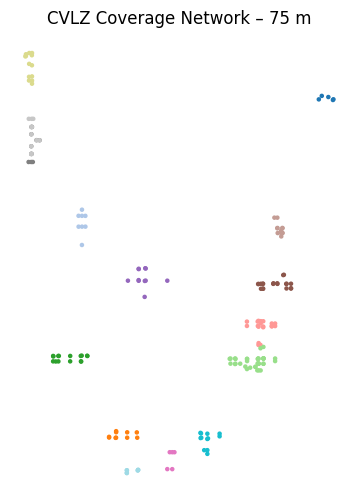

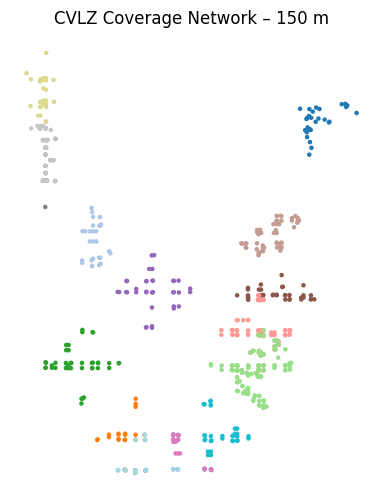

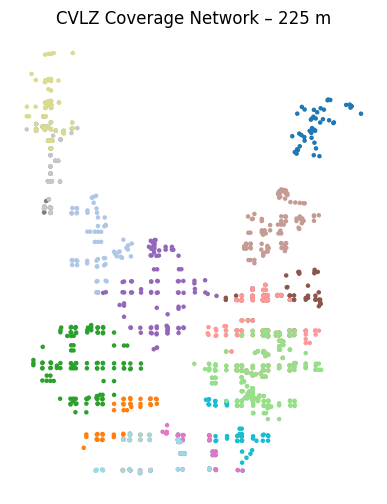

In [ ]:
import matplotlib.pyplot as plt

def plot_threshold(gdf_thresh, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    gdf_thresh.plot(
        ax=ax,
        column="BLOCKID",
        markersize=5,
        legend=False,
        cmap="tab20"
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

plot_threshold(gdf_75,  "CVLZ Coverage Network – 75 m")
plot_threshold(gdf_150, "CVLZ Coverage Network – 150 m")
plot_threshold(gdf_225, "CVLZ Coverage Network – 225 m")
